# Análisis visual del dataset limpio

Gráficas de análisis sobre el dataset (`data/processed/airprice_clean.csv`).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RUTA = "../../data/processed/airprice_clean.csv"

df = pd.read_csv(RUTA)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Faltantes:", df.isna().sum().sum())

Filas: 61617
Columnas: 32
Faltantes: 0


## 1. Análisis univariado del precio

Histograma + KDE y boxplot para observar la distribución de `price_clean` y detectar asimetría/outliers.

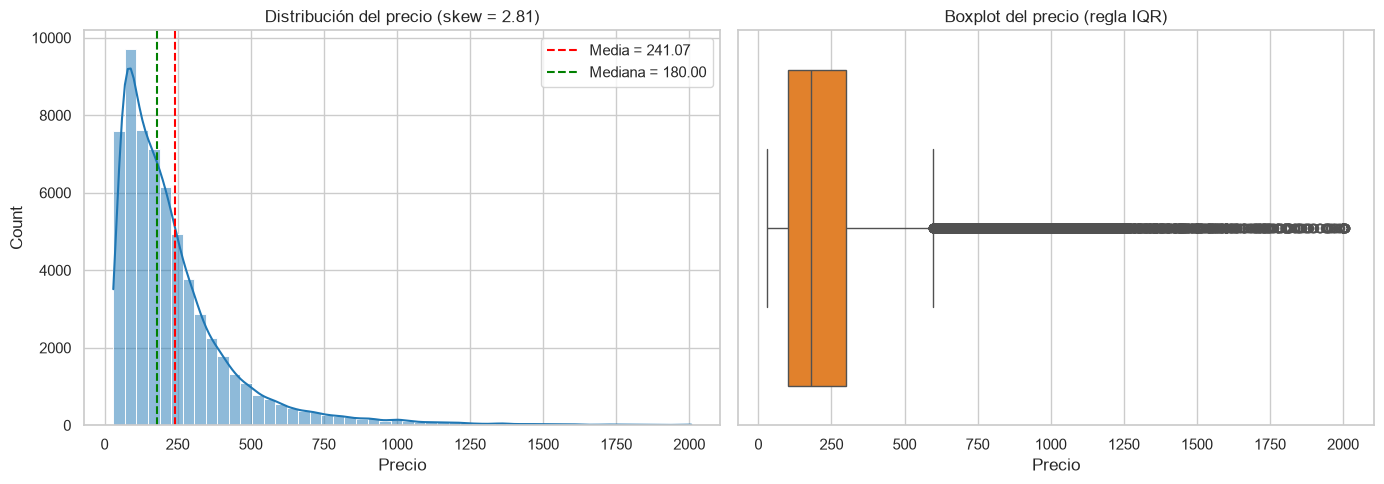

In [15]:
precio = df["price_clean"]
skew = precio.skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(precio, kde=True, bins=50, ax=axes[0], color="#1f77b4")
axes[0].axvline(precio.mean(), color="red", ls="--", label=f"Media = {precio.mean():.2f}")
axes[0].axvline(precio.median(), color="green", ls="--", label=f"Mediana = {precio.median():.2f}")
axes[0].set_title(f"Distribución del precio (skew = {skew:.2f})")
axes[0].set_xlabel("Precio")
axes[0].legend()

sns.boxplot(x=precio, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Boxplot del precio (regla IQR)")
axes[1].set_xlabel("Precio")

plt.tight_layout()
plt.show()

El skew > 1 indica asimetría positiva (cola larga a la derecha). Se compara con la transformación logarítmica para suavizarla.

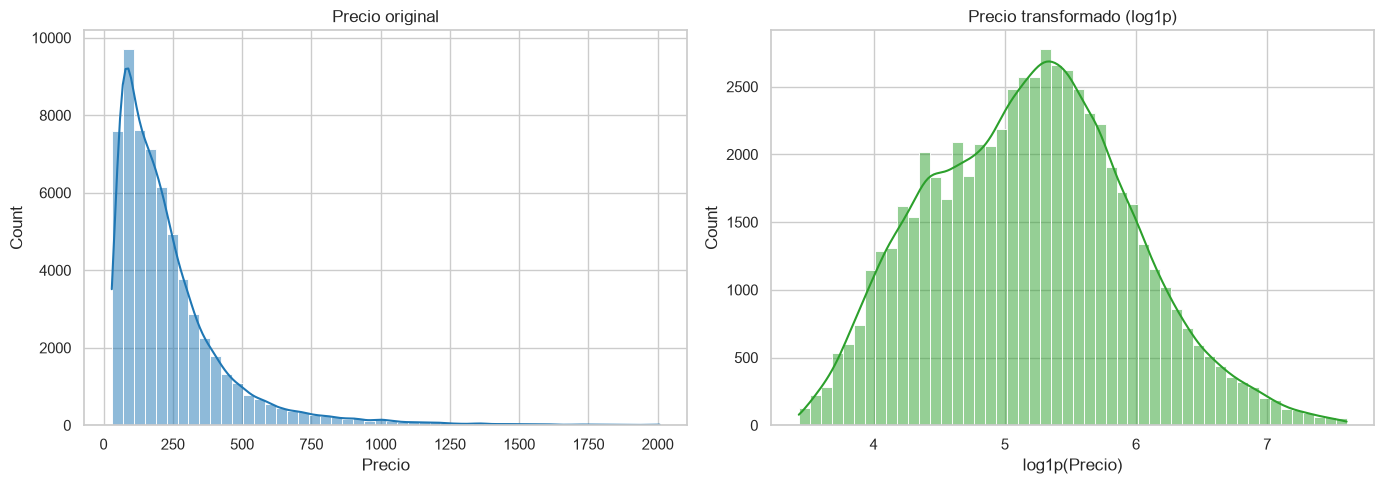

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(precio, kde=True, bins=50, ax=axes[0], color="#1f77b4")
axes[0].set_title("Precio original")
axes[0].set_xlabel("Precio")

sns.histplot(np.log1p(precio), kde=True, bins=50, ax=axes[1], color="#2ca02c")
axes[1].set_title("Precio transformado (log1p)")
axes[1].set_xlabel("log1p(Precio)")

plt.tight_layout()
plt.show()

## 2. Variables categóricas

Balance de clases (`price_range`) y distribución de las principales variables categóricas.

C:\Users\danna\AppData\Local\Temp\ipykernel_18440\15857636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


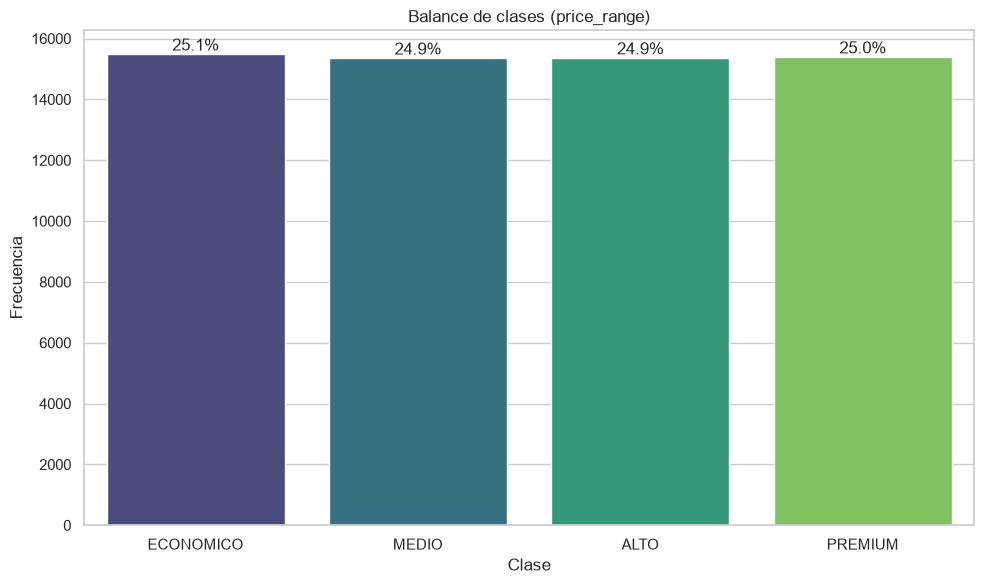

In [17]:
orden_clases = ["ECONOMICO", "MEDIO", "ALTO", "PREMIUM"]

ax = sns.countplot(
    data=df,
    x="price_range",
    order=orden_clases,
    palette="viridis"
)
ax.set_title("Balance de clases (price_range)")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")

for p in ax.patches:
    pct = 100 * p.get_height() / len(df)
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

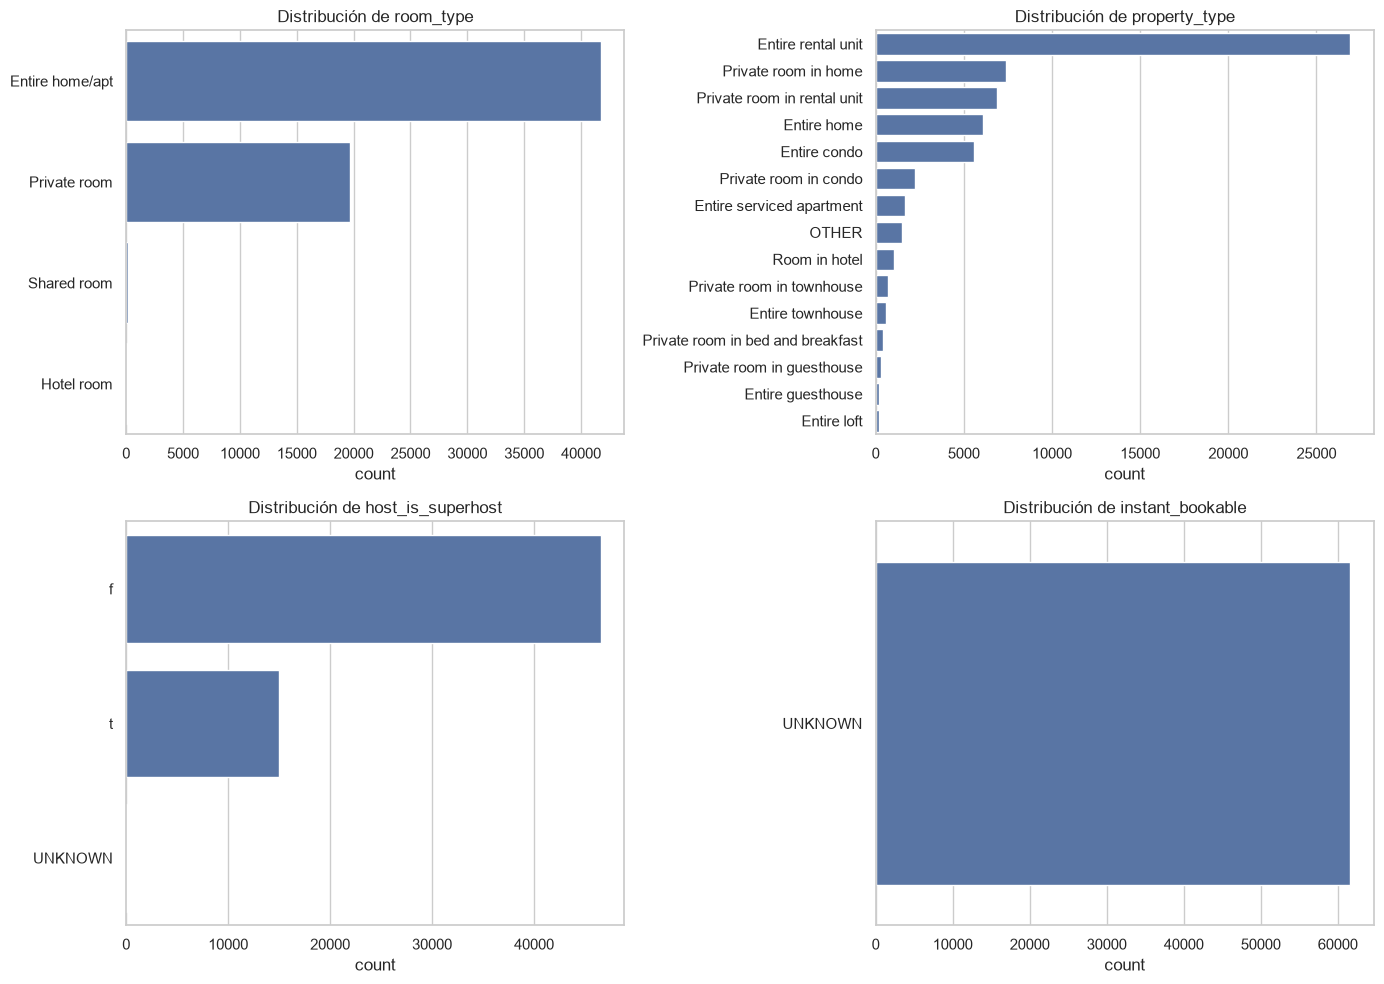

In [18]:
categoricas = ["room_type", "property_type", "host_is_superhost", "instant_bookable"]
categoricas = [c for c in categoricas if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df, y=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

C:\Users\danna\AppData\Local\Temp\ipykernel_18440\828868296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_barrios.values, y=top_barrios.index, palette="crest")


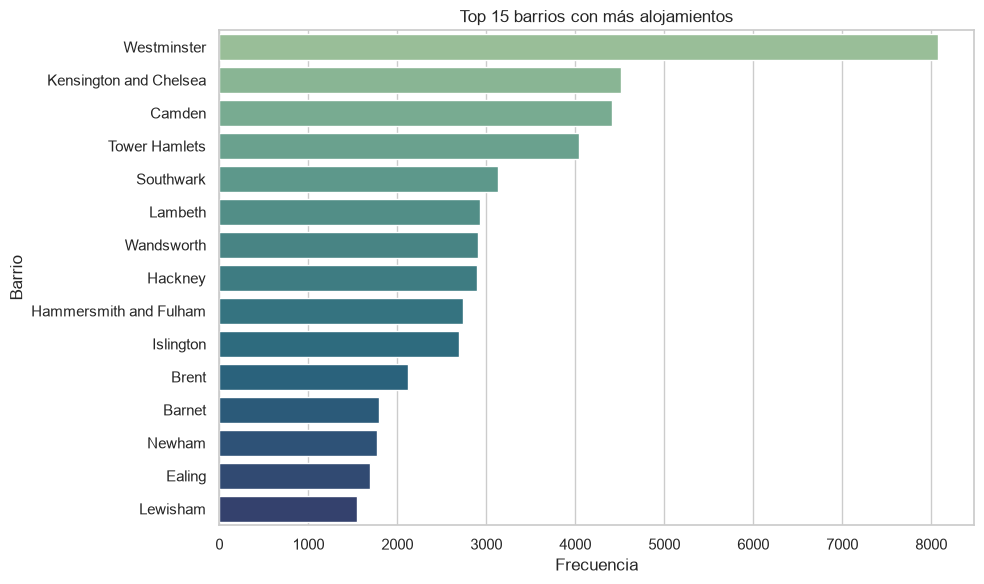

In [19]:
top_barrios = df["neighbourhood_cleansed"].value_counts().head(15)

ax = sns.barplot(x=top_barrios.values, y=top_barrios.index, palette="crest")
ax.set_title("Top 15 barrios con más alojamientos")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Barrio")
plt.tight_layout()
plt.show()

## 3. Análisis bivariado

Relación entre el precio y las principales variables de tipo y capacidad.

C:\Users\danna\AppData\Local\Temp\ipykernel_18440\1781483468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="price_clean", ax=axes[0], palette="Set2")
C:\Users\danna\AppData\Local\Temp\ipykernel_18440\1781483468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="room_type", y="price_clean", ax=axes[1], palette="Set2")


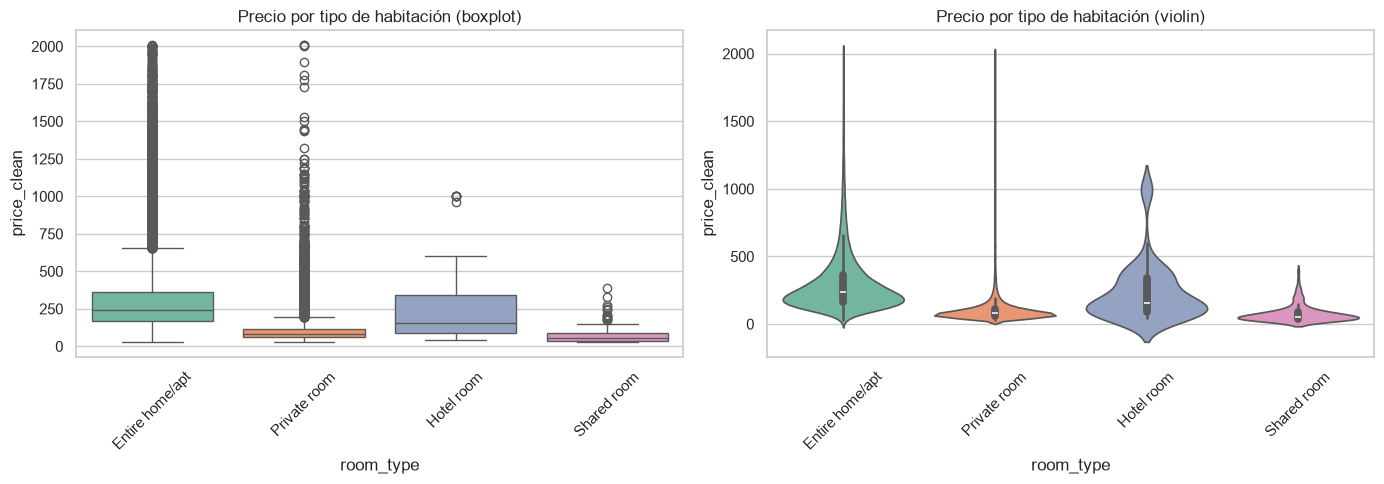

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="room_type", y="price_clean", ax=axes[0], palette="Set2")
axes[0].set_title("Precio por tipo de habitación (boxplot)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=df, x="room_type", y="price_clean", ax=axes[1], palette="Set2")
axes[1].set_title("Precio por tipo de habitación (violin)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

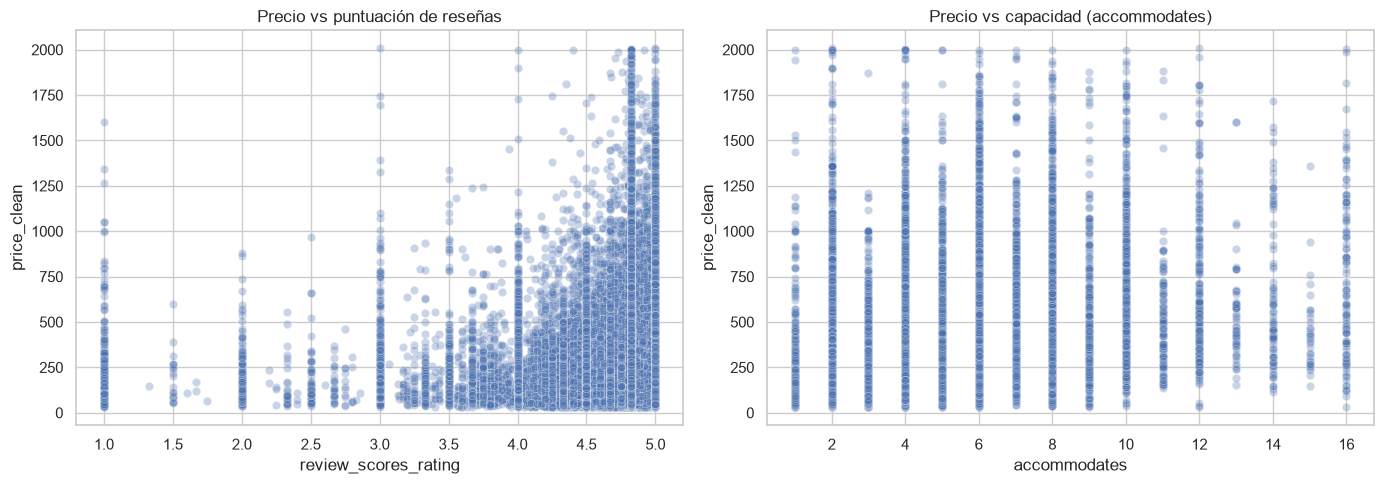

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="review_scores_rating", y="price_clean", alpha=0.3, ax=axes[0])
axes[0].set_title("Precio vs puntuación de reseñas")

sns.scatterplot(data=df, x="accommodates", y="price_clean", alpha=0.3, ax=axes[1])
axes[1].set_title("Precio vs capacidad (accommodates)")

plt.tight_layout()
plt.show()

## 4. Análisis multivariado

Matriz de correlación triangular entre las variables numéricas para detectar multicolinealidad (|r| > 0.85).

In [22]:
numericas = df.select_dtypes(
    include=[np.number]
).copy()

numericas = numericas.drop(
    columns=["id"],
    errors="ignore"
)

corr = numericas.corr(method="pearson")

In [23]:
correlacion_precio = (
    corr["price_clean"]
    .drop("price_clean")
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlacion_precio

accommodates                        0.553206
bedrooms                            0.493745
beds                                0.433912
bathrooms_num                       0.427394
bedrooms_missing                   -0.324464
amenities_count                     0.261871
number_of_reviews                  -0.094122
longitude                          -0.080531
availability_365                    0.079051
has_reviews                        -0.074703
reviews_per_month_missing           0.074703
review_scores_rating_missing        0.074703
reviews_per_month                  -0.060830
review_scores_rating                0.054030
beds_missing                       -0.053341
bathrooms_num_missing              -0.025112
minimum_nights                     -0.017882
latitude                           -0.007989
minimum_nights_missing              0.001507
host_response_rate_num                   NaN
host_acceptance_rate_num                 NaN
host_response_rate_num_missing           NaN
host_accep

In [24]:
top_corr_precio = (
    correlacion_precio
    .head(15)
)

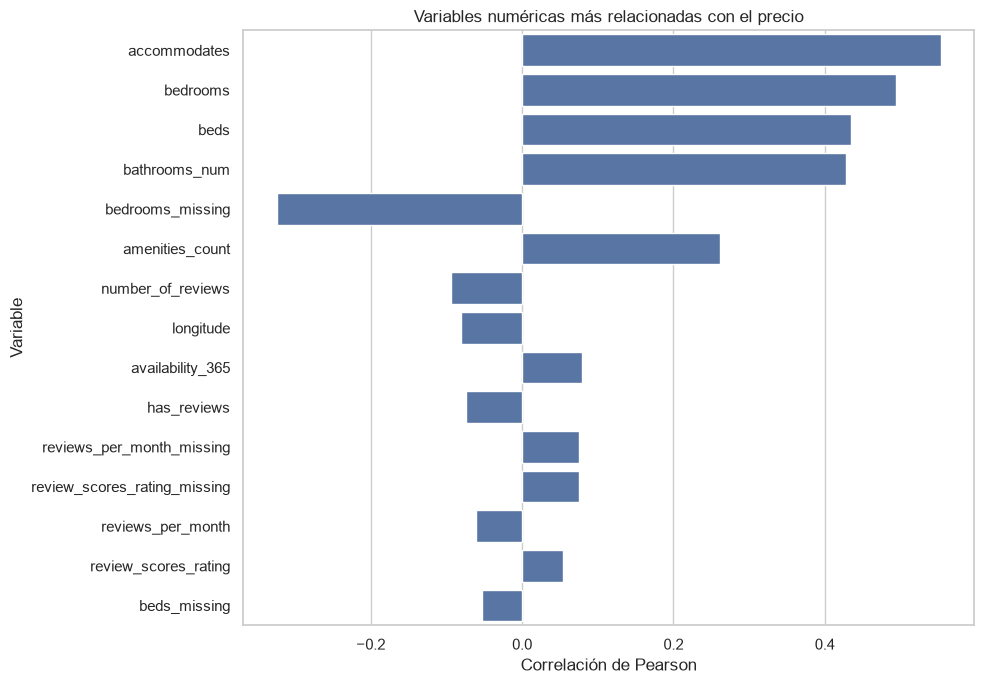

In [25]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_corr_precio.values,
    y=top_corr_precio.index
)

plt.title(
    "Variables numéricas más relacionadas con el precio"
)

plt.xlabel(
    "Correlación de Pearson"
)

plt.ylabel(
    "Variable"
)

plt.tight_layout()

plt.show()

> **Nota:** La correlación de Pearson mide relaciones lineales. Una correlación baja no significa necesariamente que una variable no sea útil para los modelos, ya que algoritmos como XGBoost y LightGBM pueden capturar relaciones no lineales e interacciones entre variables.

### Interpretación de la correlación con el precio

Las variables numéricas con mayor relación lineal positiva con `price_clean` son:

- `accommodates` con una correlación de **0.553**
- `bedrooms` con **0.494**
- `beds` con **0.434**
- `bathrooms_num` con **0.427**
- `amenities_count` con **0.262**

Esto indica que, dentro del dataset analizado, los alojamientos con mayor capacidad, más habitaciones, más camas, más baños y una mayor cantidad de servicios tienden a estar asociados con precios más altos.

La variable `bedrooms_missing` presenta una correlación negativa de **-0.324**, lo que sugiere que los registros en los que originalmente faltaba información sobre habitaciones tienden a asociarse con precios menores.

Por otro lado, variables como `number_of_reviews`, `longitude`, `availability_365`, `reviews_per_month`, `review_scores_rating`, `minimum_nights` y `latitude` presentan correlaciones lineales débiles con el precio, ya que sus valores se encuentran cercanos a cero.

Las variables relacionadas con tasas del anfitrión (`host_response_rate_num` y `host_acceptance_rate_num`) aparecen con valores `NaN` en la matriz de correlación. Esto ocurre cuando una variable no tiene variación suficiente o presenta un comportamiento que impide calcular el coeficiente de Pearson.

En general, los resultados muestran que las características estructurales del alojamiento, especialmente la capacidad y el número de habitaciones, presentan una relación lineal más clara con el precio que las variables de reseñas, disponibilidad o ubicación expresada únicamente mediante latitud y longitud.

Estas correlaciones no implican causalidad y se utilizan únicamente como apoyo exploratorio para las etapas posteriores de preprocesamiento y modelado.

In [27]:
correlacion_precio

accommodates                        0.553206
bedrooms                            0.493745
beds                                0.433912
bathrooms_num                       0.427394
bedrooms_missing                   -0.324464
amenities_count                     0.261871
number_of_reviews                  -0.094122
longitude                          -0.080531
availability_365                    0.079051
has_reviews                        -0.074703
reviews_per_month_missing           0.074703
review_scores_rating_missing        0.074703
reviews_per_month                  -0.060830
review_scores_rating                0.054030
beds_missing                       -0.053341
bathrooms_num_missing              -0.025112
minimum_nights                     -0.017882
latitude                           -0.007989
minimum_nights_missing              0.001507
host_response_rate_num                   NaN
host_acceptance_rate_num                 NaN
host_response_rate_num_missing           NaN
host_accep

### Conclusión del análisis de correlación

No se identificaron pares de variables numéricas con una correlación absoluta superior a 0.85, por lo que no se evidencian relaciones lineales extremadamente altas que sugieran multicolinealidad severa entre las variables analizadas.

Las variables con mayor relación lineal con `price_clean` fueron `accommodates`, `bedrooms`, `beds` y `bathrooms_num`, mientras que otras variables como valoraciones, disponibilidad, número de reseñas y coordenadas presentaron relaciones lineales débiles.

Estos resultados se utilizarán como referencia para las siguientes fases de preprocesamiento y modelado.